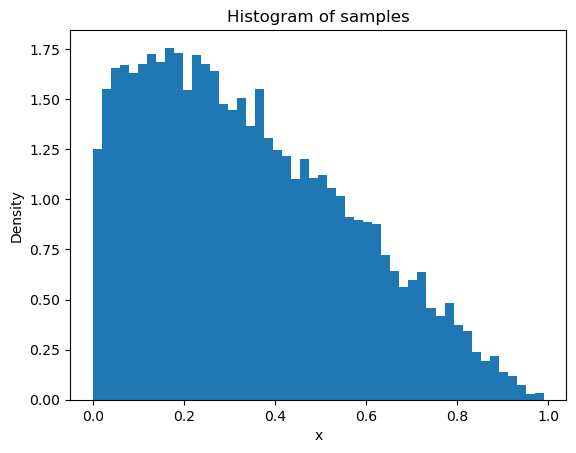

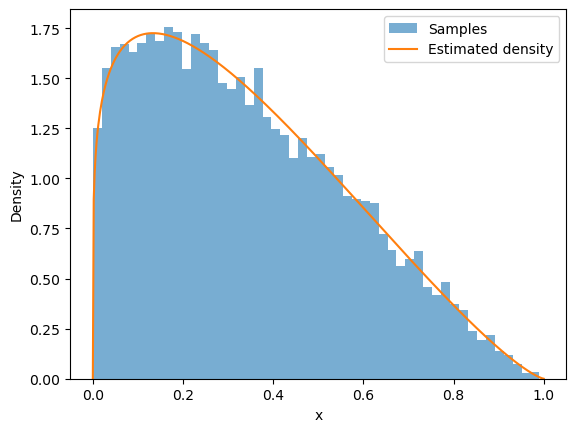

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def problem1_rejection(n_samples=1):  #this is june 2024 QUESTION 1 DENSITY ONE f(x)=Cx0.2(1−x)1.3So:h(x)=x0.2(1−x)1.3 Range:0≤x≤1
    samples = []
    
    # h(x) = x^0.2 (1-x)^1.3
    # Maximum happens at x = a/(a+b)
    a = 0.2
    b = 1.3
    x_star = a / (a + b)
    
    M = x_star**a * (1 - x_star)**b
    
    while len(samples) < n_samples:
        x = np.random.uniform(0, 1, size=n_samples)
        u = np.random.uniform(0, 1, size=n_samples)
        
        h = x**0.2 * (1-x)**1.3
        
        accepted = x[u <= h/M]
        
        samples.extend(accepted)
    
    return np.array(samples[:n_samples])

    #part 2

problem1_samples = problem1_rejection(10000)
import matplotlib.pyplot as plt

plt.hist(problem1_samples, bins=50, density=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram of samples")
plt.show()

#part 3

Y = np.sin(10 * problem1_samples)

problem1_expectation = float(np.mean(Y))

problem1_expectation

#part 4 
delta = 0.05
n = len(Y)

a = -1
b = 1

epsilon = (b - a) * np.sqrt(np.log(2/delta) / (2*n))

problem1_interval = (
    float(problem1_expectation - epsilon),
    float(problem1_expectation + epsilon)
)

problem1_interval

#part 5 approximation  Range:0≤x≤1

# Part 5: approximate C

u = np.random.uniform(0, 1, size=100000)

h_u = u**0.2 * (1-u)**1.3

integral_estimate = np.mean(h_u)

problem1_c = float(1 / integral_estimate)

problem1_c
#plot

xs = np.linspace(0, 1, 500)

density = problem1_c * xs**0.2 * (1-xs)**1.3

plt.hist(problem1_samples, bins=50, density=True, alpha=0.6, label="Samples")
plt.plot(xs, density, label="Estimated density")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

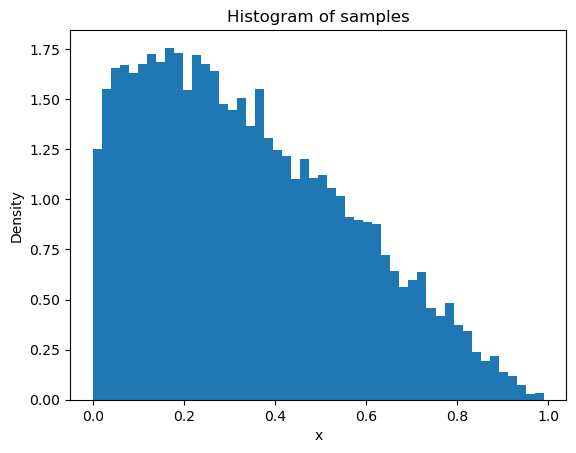

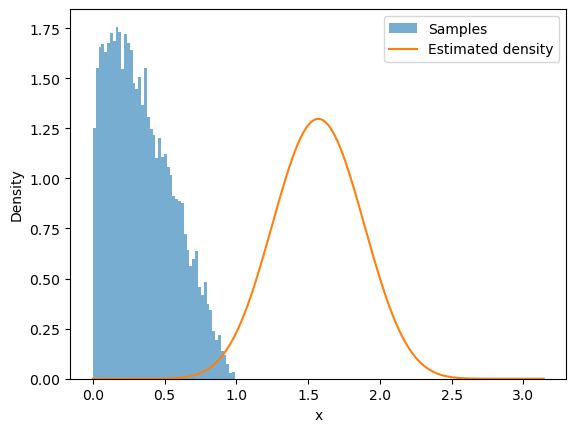

In [2]:
import numpy as np
import matplotlib.pyplot as plt    # this is august 2024 QUESTION 1    f(x)=Csin10(x)So:h(x)=sin10(x)

def problem1_rejection(n_samples=1):
    samples = []
    
    while len(samples) < n_samples:
        # propose x from Uniform(0, pi)
        x = np.random.uniform(0, np.pi, size=n_samples)
        
        # propose u from Uniform(0, 1)
        u = np.random.uniform(0, 1, size=n_samples)
        
        # h(x) = sin(x)^10, max value is 1
        accepted = x[u <= np.sin(x)**10]
        
        samples.extend(accepted)
    
    return np.array(samples[:n_samples])

    
    # Part 2

    problem1_samples = problem1_rejection(10000)

plt.hist(problem1_samples, bins=50, density=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram of samples")
plt.show()

# Part 3
Y = np.sin(10 * problem1_samples)

problem1_expectation = float(np.mean(Y))

problem1_expectation

#part 4 
delta = 0.05
n = len(Y)

a = 0
b = (np.pi/2)**2

epsilon = (b - a) * np.sqrt(np.log(2/delta) / (2*n))

problem1_interval = (
    float(problem1_expectation - epsilon),
    float(problem1_expectation + epsilon)
)

problem1_interval

#part 5 approximation  Range:0≤x≤π

# Part 5: approximate C

u = np.random.uniform(0, np.pi, size=100000)

h_u = np.sin(u)**10

integral_estimate = np.pi * np.mean(h_u)

problem1_c = float(1 / integral_estimate)

problem1_c

# plot

xs = np.linspace(0, np.pi, 500)

density = problem1_c * np.sin(xs)**10

plt.hist(problem1_samples, bins=50, density=True, alpha=0.6, label="Samples")
plt.plot(xs, density, label="Estimated density")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

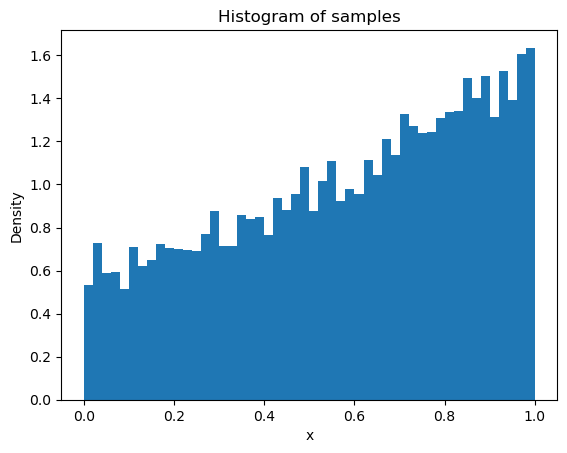

In [3]:
import numpy as np
import matplotlib.pyplot as plt   # JANUARY 2024  QUESTION 1 CDF ONE 

# Part 1
def problem1_inversion(n_samples=1):
    u = np.random.uniform(0, 1, size=n_samples)
    x = np.log(1 + u * (np.e - 1))
    return x


# Part 2
problem1_samples = problem1_inversion(10000)

plt.hist(problem1_samples, bins=50, density=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram of samples")
plt.show()


# Part 3
Y = np.sin(problem1_samples)

problem1_integral = float(np.mean(Y))


# Part 4
delta = 0.05
n = len(Y)

a = 0
b = np.sin(1)

epsilon = (b - a) * np.sqrt(np.log(2/delta) / (2*n))

problem1_interval = (
    float(problem1_integral - epsilon),
    float(problem1_integral + epsilon)
)


# Part 5
def problem1_inversion_2(n_samples=1):
    samples = []
    
    while len(samples) < n_samples:
        x = np.random.uniform(0, 1/20, size=n_samples)
        u = np.random.uniform(0, 1, size=n_samples)
        
        accept_prob = np.exp(20*x - 1) * (1 + 20*x) / 2
        
        accepted = x[u <= accept_prob]
        
        samples.extend(accepted)
    
    return np.array(samples[:n_samples])

In [4]:
import pandas as pd    # LOGISTIC REGRESSION PROBLEM
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Part 1
spam_df = pd.read_csv("data/spam.csv", encoding="latin1")

texts = spam_df["v2"].astype(str).str.lower()

problem2_X = np.column_stack([
    texts.str.contains("free").astype(int).values,
    texts.str.contains("prize").astype(int).values,
    texts.str.contains("win").astype(int).values
]).astype(float)

problem2_Y = (spam_df["v1"] == "spam").astype(int).to_numpy()

n = problem2_X.shape[0]

n_train = int(0.4 * n)
n_calib = int(0.2 * n)

problem2_X_train = problem2_X[:n_train]
problem2_X_calib = problem2_X[n_train:n_train+n_calib]
problem2_X_test = problem2_X[n_train+n_calib:]

problem2_Y_train = problem2_Y[:n_train]
problem2_Y_calib = problem2_Y[n_train:n_train+n_calib]
problem2_Y_test = problem2_Y[n_train+n_calib:]


# Part 2
class ProportionalSpam(object):
    def __init__(self):
        self.coeffs = None
        self.result = None
    
    def loss(self, X, Y, coeffs):
        import numpy as np
        
        z = coeffs[0] + np.dot(X, coeffs[1:])
        
        p = 1 / (1 + np.exp(-z))
        
        p = np.clip(p, 1e-15, 1 - 1e-15)
        
        return -np.mean(Y * np.log(p) + (1 - Y) * np.log(1 - p))

    def fit(self, X, Y):
        import numpy as np
        from scipy import optimize
        
        opt_loss = lambda coeffs: self.loss(X, Y, coeffs)
        
        initial_arguments = np.zeros(shape=X.shape[1] + 1)
        
        self.result = optimize.minimize(
            opt_loss,
            initial_arguments,
            method="cg"
        )
        
        self.coeffs = self.result.x
    
    def predict(self, X):
        if self.coeffs is not None:
            G = lambda x: np.exp(x) / (1 + np.exp(x))
            
            return np.round(
                10 * G(np.dot(X, self.coeffs[1:]) + self.coeffs[0])
            ) / 10


# Part 3
problem2_ps = ProportionalSpam()

problem2_ps.fit(problem2_X_train, problem2_Y_train)

problem2_X_pred = problem2_ps.predict(problem2_X_calib).reshape(-1, 1)

problem2_calibrator = DecisionTreeRegressor()

problem2_calibrator.fit(problem2_X_pred, problem2_Y_calib)


# Part 4
test_pred_raw = problem2_ps.predict(problem2_X_test).reshape(-1, 1)

problem2_final_predictions = problem2_calibrator.predict(test_pred_raw)

problem2_test_labels = (problem2_final_predictions >= 0.5).astype(int)

problem2_01_loss = float(np.mean(problem2_test_labels != problem2_Y_test))

delta = 0.10
n_test = len(problem2_Y_test)

epsilon = np.sqrt(np.log(2/delta) / (2*n_test))

problem2_interval = (
    float(problem2_01_loss - epsilon),
    float(problem2_01_loss + epsilon)
)

<class 'FileNotFoundError'>: [Errno 44] No such file or directory: 'data/spam.csv'

In [6]:
import numpy as np

# Chain A: states A,B,C,D
problem3_A = np.array([
    [0.8, 0.2, 0.0, 0.0],
    [0.6, 0.2, 0.2, 0.0],
    [0.0, 0.4, 0.0, 0.6],
    [0.0, 0.0, 0.8, 0.2]
])

# Chain B: states A,B,C,D
problem3_B = np.array([
    [0.0, 0.2, 0.0, 0.8],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0]
])

# Chain C: states A,B,C,D,E
problem3_C = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.2, 0.2, 0.6, 0.0, 0.0],
    [0.0, 0.4, 0.0, 0.6, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.4, 0.6]
])

# Chain D: states A,B,C,D
problem3_D = np.array([
    [0.8, 0.2, 0.0, 0.0],
    [0.6, 0.2, 0.2, 0.0],
    [0.0, 0.4, 0.0, 0.6],
    [0.1, 0.0, 0.7, 0.2]
])

#PART 2

def is_irreducible(P):
    n = P.shape[0]
    
    # True if there is an arrow from i to j
    A = P > 0
    
    # reach[i,j] means: can i reach j?
    reach = np.eye(n, dtype=bool)
    
    power = np.eye(n, dtype=bool)
    
    for _ in range(n):
        power = (power @ A) > 0
        reach = reach | power
    
    return bool(reach.all())

problem3_A_irreducible = is_irreducible(problem3_A)
problem3_B_irreducible = is_irreducible(problem3_B)
problem3_C_irreducible = is_irreducible(problem3_C)
problem3_D_irreducible = is_irreducible(problem3_D)

print(problem3_A_irreducible)
print(problem3_B_irreducible)
print(problem3_C_irreducible)
print(problem3_D_irreducible)

True
False
False
True


In [8]:
import numpy as np
import math

def state_period(P, state, max_steps=50):
    n = P.shape[0]
    
    # Convert probabilities to arrows
    # True means there is an arrow
    A = P > 0
    
    # power will store paths of exact length k
    power = np.eye(n, dtype=bool)
    
    return_times = []
    
    for k in range(1, max_steps + 1):
        power = (power @ A) > 0
        
        # If state can return to itself in exactly k steps
        if power[state, state]:
            return_times.append(k)
    
    # Take gcd of all return times
    d = 0
    for t in return_times:
        d = math.gcd(d, t)
    
    return d


def periods(P, max_steps=50):
    n = P.shape[0]
    return np.array([state_period(P, i, max_steps) for i in range(n)])


def is_aperiodic(P, max_steps=50):
    p = periods(P, max_steps)
    return bool(np.all(p == 1))


problem3_A_periods = periods(problem3_A)
problem3_B_periods = periods(problem3_B)
problem3_C_periods = periods(problem3_C)
problem3_D_periods = periods(problem3_D)

problem3_A_is_aperiodic = is_aperiodic(problem3_A)
problem3_B_is_aperiodic = is_aperiodic(problem3_B)
problem3_C_is_aperiodic = is_aperiodic(problem3_C)
problem3_D_is_aperiodic = is_aperiodic(problem3_D)

print(problem3_A_periods, problem3_A_is_aperiodic)
print(problem3_B_periods, problem3_B_is_aperiodic)
print(problem3_C_periods, problem3_C_is_aperiodic)
print(problem3_D_periods, problem3_D_is_aperiodic)

[1 1 1 1] True
[2 2 2 2] False
[1 1 1 1 1] True
[1 1 1 1] True


In [17]:
#PART 4 STATIONARY

import numpy as np

def stationary_distribution(P):
    n = P.shape[0]
    
    # Solve pi P = pi
    # Equivalent to: (P.T - I) pi = 0
    A = P.T - np.eye(n)
    
    # Replace last equation with sum(pi)=1
    A[-1, :] = np.ones(n)
    
    b = np.zeros(n)
    b[-1] = 1
    
    pi = np.linalg.solve(A, b)
    
    # Clean tiny numerical errors
    pi[np.abs(pi) < 1e-12] = 0
    
    return pi


def has_stationary(P):
    try:
        pi = stationary_distribution(P)
        return bool(
            np.all(pi >= -1e-9) and 
            np.allclose(pi @ P, pi, atol=1e-9) and 
            np.allclose(np.sum(pi), 1, atol=1e-9)
        )
    except:
        return False

problem3_A_has_stationary = has_stationary(problem3_A)
problem3_B_has_stationary = has_stationary(problem3_B)
problem3_C_has_stationary = has_stationary(problem3_C)
problem3_D_has_stationary = has_stationary(problem3_D)

problem3_A_stationary_dist = stationary_distribution(problem3_A)
problem3_B_stationary_dist = stationary_distribution(problem3_B)
problem3_C_stationary_dist = stationary_distribution(problem3_C)
problem3_D_stationary_dist = stationary_distribution(problem3_D)

print("A has stationary:", problem3_A_has_stationary)
print("A stationary distribution:", problem3_A_stationary_dist)

print("B has stationary:", problem3_B_has_stationary)
print("B stationary distribution:", problem3_B_stationary_dist)

print("C has stationary:", problem3_C_has_stationary)
print("C stationary distribution:", problem3_C_stationary_dist)

print("D has stationary:", problem3_D_has_stationary)
print("D stationary distribution:", problem3_D_stationary_dist)

A has stationary: True
A stationary distribution: [0.61538462 0.20512821 0.1025641  0.07692308]
B has stationary: True
B stationary distribution: [0.  0.5 0.5 0. ]
C has stationary: True
C stationary distribution: [0.  0.  0.  0.5 0.5]
D has stationary: True
D stationary distribution: [0.64516129 0.20430108 0.08602151 0.06451613]


In [18]:
import numpy as np #PART 5 

def is_reversible(P, pi, tol=1e-9):
    flow = pi[:, None] * P
    return bool(np.allclose(flow, flow.T, atol=tol))

problem3_A_is_reversible = is_reversible(problem3_A, problem3_A_stationary_dist)
problem3_B_is_reversible = is_reversible(problem3_B, problem3_B_stationary_dist)
problem3_C_is_reversible = is_reversible(problem3_C, problem3_C_stationary_dist)
problem3_D_is_reversible = is_reversible(problem3_D, problem3_D_stationary_dist)

print(problem3_A_is_reversible)
print(problem3_B_is_reversible)
print(problem3_C_is_reversible)
print(problem3_D_is_reversible)
    

True
True
True
False


In [19]:
#data coris 28th august 2024

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load data
CORISDataset = pd.read_csv("data/CORIS.csv", skiprows=[1,2])

# Features
problem2_X = CORISDataset[
    ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 
     'typea', 'obesity', 'alcohol', 'age']
].values

# Target
problem2_Y = CORISDataset['chd'].values

# Split into train, test, validation
problem2_X_train, tmp, problem2_Y_train, tmp_y = train_test_split(
    problem2_X,
    problem2_Y,
    train_size=0.6,
    random_state=42
)

problem2_X_test, problem2_X_val, problem2_Y_test, problem2_Y_val = train_test_split(
    tmp,
    tmp_y,
    train_size=0.5,
    random_state=42
)

# Create pipeline
problem2_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42))
])

# Train model
problem2_pipe.fit(problem2_X_train, problem2_Y_train)

#### Part 1

import numpy as np

def hoeffding_interval(p_hat, n, delta=0.05):
    if n == 0:
        return (0.0, 1.0)
    
    eps = np.sqrt(np.log(2/delta) / (2*n))
    
    lower = max(0.0, p_hat - eps)
    upper = min(1.0, p_hat + eps)
    
    return (float(lower), float(upper))


problem2_test_predictions = problem2_pipe.predict(problem2_X_test)


def precision_interval_for_class(y_true, y_pred, cls, delta=0.05):
    mask = (y_pred == cls)
    n = np.sum(mask)
    
    if n == 0:
        return (0.0, 1.0)
    
    p_hat = np.mean(y_true[mask] == cls)
    
    return hoeffding_interval(p_hat, n, delta)


def recall_interval_for_class(y_true, y_pred, cls, delta=0.05):
    mask = (y_true == cls)
    n = np.sum(mask)
    
    if n == 0:
        return (0.0, 1.0)
    
    p_hat = np.mean(y_pred[mask] == cls)
    
    return hoeffding_interval(p_hat, n, delta)


problem2_precision0 = precision_interval_for_class(
    problem2_Y_test,
    problem2_test_predictions,
    0
)

problem2_recall0 = recall_interval_for_class(
    problem2_Y_test,
    problem2_test_predictions,
    0
)

problem2_precision1 = precision_interval_for_class(
    problem2_Y_test,
    problem2_test_predictions,
    1
)

problem2_recall1 = recall_interval_for_class(
    problem2_Y_test,
    problem2_test_predictions,
    1
)

print("precision0:", problem2_precision0)
print("recall0:", problem2_recall0)
print("precision1:", problem2_precision1)
print("recall1:", problem2_recall1)

##part 2
def problem2_cost(model, threshold, X, Y):
    pred_proba = model.predict_proba(X)[:, 1]
    
    predictions = (pred_proba >= threshold) + 0
    
    false_negative = (Y == 1) & (predictions == 0)
    false_positive = (Y == 0) & (predictions == 1)
    
    costs = 300 * false_negative + 10 * false_positive
    
    return float(np.mean(costs))

##ppart 3

thresholds = np.linspace(0, 1, 1000)

costs = np.array([
    problem2_cost(problem2_pipe, threshold, problem2_X_test, problem2_Y_test)
    for threshold in thresholds
])

best_index = np.argmin(costs)

problem2_optimal_threshold = float(thresholds[best_index])
problem2_cost_at_optimal_threshold = float(costs[best_index])

print("Best threshold:", problem2_optimal_threshold)
print("Cost at best threshold:", problem2_cost_at_optimal_threshold)


## part 4

problem2_cost_at_optimal_threshold_validation = problem2_cost(
    problem2_pipe,
    problem2_optimal_threshold,
    problem2_X_val,
    problem2_Y_val
)

delta = 0.01
n = len(problem2_Y_val)

eps = 300 * np.sqrt(np.log(2/delta) / (2*n))

lower = max(0.0, problem2_cost_at_optimal_threshold_validation - eps)
upper = problem2_cost_at_optimal_threshold_validation + eps

problem2_cost_interval = (float(lower), float(upper))

print("Validation cost:", problem2_cost_at_optimal_threshold_validation)
print("99% cost interval:", problem2_cost_interval)


<class 'NameError'>: name 'problem2_pipe' is not defined

In [21]:
## matrix another 28th august 2024

import numpy as np

# states
A, B, C, D = 0, 1, 2, 3

# create empty 4x4 matrix
problem_A = np.zeros((4, 4))

# fill arrows
problem_A[A, B] = 0.2
problem_A[A, D] = 0.8

problem_A[B, C] = 1.0

problem_A[C, B] = 1.0

problem_A[D, A] = 0.5
problem_A[D, C] = 0.5

problem_A
##answer

import numpy as np

problem_A = np.array([
    [0.0, 0.2, 0.0, 0.8],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0]
])

# states
A, B, C, D, E, F = 0, 1, 2, 3, 4, 5

# create empty 6x6 matrix
problem_B = np.zeros((6, 6))

# fill arrows
problem_B[A, B] = 1.0

problem_B[B, C] = 1.0

problem_B[C, B] = 0.5
problem_B[C, D] = 0.5

problem_B[D, C] = 0.5
problem_B[D, E] = 0.5

problem_B[E, F] = 1.0

problem_B[F, A] = 0.5
problem_B[F, E] = 0.5

problem_B

##answer
problem_B = np.array([
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 0.5, 0.0, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.5, 0.0, 0.5, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    [0.5, 0.0, 0.0, 0.0, 0.5, 0.0]
])

In [22]:
##part 2 markov chain

import numpy as np

def is_irreducible(P):
    n = P.shape[0]
    
    # True means there is an arrow
    A = P > 0
    
    # reach[i,j] means can i reach j
    reach = np.eye(n, dtype=bool)
    
    power = np.eye(n, dtype=bool)
    
    for _ in range(n):
        power = (power @ A) > 0
        reach = reach | power
    
    return bool(reach.all())

problem_A_irreducible = is_irreducible(problem_A)
problem_B_irreducible = is_irreducible(problem_B)

print(problem_A_irreducible)
print(problem_B_irreducible)

False
True


In [24]:
##part 3 markov chain
import numpy as np
import math

def state_period(P, state, max_steps=50):
    n = P.shape[0]
    
    # arrows: True if probability > 0
    A = P > 0
    
    # paths of exact length k
    power = np.eye(n, dtype=bool)
    
    return_times = []
    
    for k in range(1, max_steps + 1):
        power = (power @ A) > 0
        
        if power[state, state]:
            return_times.append(k)
    
    d = 0
    for t in return_times:
        d = math.gcd(d, t)
    
    return d


def periods(P, max_steps=50):
    n = P.shape[0]
    return np.array([state_period(P, i, max_steps) for i in range(n)])


def is_aperiodic(P):
    p = periods(P)
    return bool(np.all(p == 1))

problem_A_periods = periods(problem_A)
problem_B_periods = periods(problem_B)

problem_A_is_aperiodic = is_aperiodic(problem_A)
problem_B_is_aperiodic = is_aperiodic(problem_B)

print(problem_A_periods)
print(problem_A_is_aperiodic)

print(problem_B_periods)
print(problem_B_is_aperiodic)
## part 3 answer
problem_A_is_aperiodic = False
problem_B_is_aperiodic = False

problem_A_periods = np.array([2, 2, 2, 2])
problem_B_periods = np.array([2, 2, 2, 2, 2, 2])

[2 2 2 2]
False
[2 2 2 2 2 2]
False


In [25]:
##part 4 markov chain

import numpy as np

P_A_5 = np.linalg.matrix_power(problem_A, 5)
P_B_5 = np.linalg.matrix_power(problem_B, 5)

problem_A_PB5 = float(P_A_5[0, 1])
problem_B_PB5 = float(P_B_5[0, 1])

print(problem_A_PB5)
print(problem_B_PB5)


0.8720000000000001
0.375


In [27]:
import numpy as np

def first_hit_probs(P, start, target, max_t=5, long_steps=500):
    n_states = P.shape[0]
    
    # Start at A
    dist = np.zeros(n_states)
    dist[start] = 1.0
    
    probs = []
    
    for t in range(1, long_steps + 1):
        # probability of first hitting target at this step
        hit_prob = float(dist @ P[:, target])
        
        if t <= max_t:
            probs.append(hit_prob)
        
        # move forward one step
        dist = dist @ P
        
        # remove paths that have already hit D
        dist[target] = 0.0
    
    # after many steps, whatever remains means never hit D
    p_inf = float(dist.sum())
    
    # clean small numerical errors
    probs = [0.0 if abs(x) < 1e-12 else float(x) for x in probs]
    p_inf = 0.0 if abs(p_inf) < 1e-12 else p_inf
    
    return probs, p_inf


# A = index 0, D = index 3
A_hit_probs, A_inf = first_hit_probs(problem_A, start=0, target=3)
B_hit_probs, B_inf = first_hit_probs(problem_B, start=0, target=3)


problem3_A_PT1 = A_hit_probs[0]
problem3_A_PT2 = A_hit_probs[1]
problem3_A_PT3 = A_hit_probs[2]
problem3_A_PT4 = A_hit_probs[3]
problem3_A_PT5 = A_hit_probs[4]
problem3_A_PT_inf = A_inf

problem3_B_PT1 = B_hit_probs[0]
problem3_B_PT2 = B_hit_probs[1]
problem3_B_PT3 = B_hit_probs[2]
problem3_B_PT4 = B_hit_probs[3]
problem3_B_PT5 = B_hit_probs[4]
problem3_B_PT_inf = B_inf


print("Chain A:")
print(problem3_A_PT1, problem3_A_PT2, problem3_A_PT3, problem3_A_PT4, problem3_A_PT5, problem3_A_PT_inf)

print("Chain B:")
print(problem3_B_PT1, problem3_B_PT2, problem3_B_PT3, problem3_B_PT4, problem3_B_PT5, problem3_B_PT_inf)

Chain A:
0.8 0.0 0.0 0.0 0.0 0.2
Chain B:
0.0 0.0 0.5 0.0 0.25 0.0
